In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report, roc_curve
)

## Task 1

In [2]:
true_values     = np.array([2.5, 3.7, 1.8, 4.0, 5.2])
predicted_values = np.array([2.1, 3.9, 1.7, 3.8, 5.0])

# From scratch
def mae_scratch(y, yhat):  return np.mean(np.abs(y - yhat))
def mse_scratch(y, yhat):  return np.mean((y - yhat) ** 2)
def rmse_scratch(y, yhat): return np.sqrt(mse_scratch(y, yhat))
def r2_scratch(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

metrics = {
    'MAE':  (mae_scratch(true_values, predicted_values),  mean_absolute_error(true_values, predicted_values)),
    'MSE':  (mse_scratch(true_values, predicted_values),  mean_squared_error(true_values, predicted_values)),
    'RMSE': (rmse_scratch(true_values, predicted_values), np.sqrt(mean_squared_error(true_values, predicted_values))),
    'R2':   (r2_scratch(true_values, predicted_values),   r2_score(true_values, predicted_values)),
}

print(f"{'Metric':<6} {'Scratch':>10} {'Sklearn':>10}")
for name, (scratch, sk) in metrics.items():
    print(f"{name:<6} {scratch:>10.4f} {sk:>10.4f}")

Metric    Scratch    Sklearn
MAE        0.2200     0.2200
MSE        0.0580     0.0580
RMSE       0.2408     0.2408
R2         0.9589     0.9589


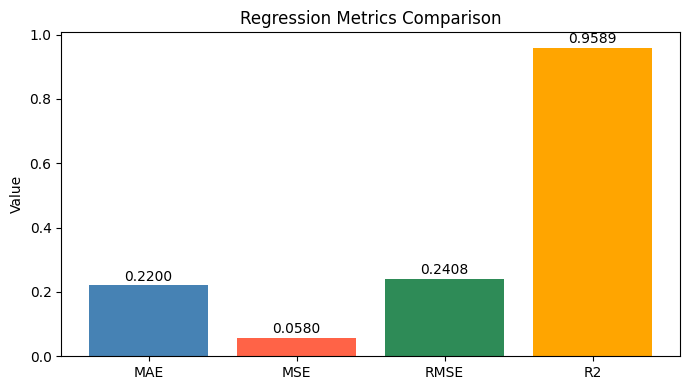

In [3]:
names  = list(metrics.keys())
values = [v[0] for v in metrics.values()]

plt.figure(figsize=(7, 4))
bars = plt.bar(names, values, color=['steelblue', 'tomato', 'seagreen', 'orange'])
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.title('Regression Metrics Comparison')
plt.ylabel('Value')
plt.tight_layout()
plt.savefig('regression_metrics.png', dpi=150)
plt.show()

## Task 2

In [4]:
pred_sets = {
    'Nearly Accurate':      np.array([2.4, 3.8, 1.9, 3.9, 5.1]),
    'Moderately Incorrect': np.array([2.0, 3.2, 1.4, 3.4, 4.6]),
    'Highly Incorrect':     np.array([1.0, 2.0, 0.5, 2.0, 3.0]),
}

results = []
for label, preds in pred_sets.items():
    results.append({
        'Case': label,
        'MAE':  mae_scratch(true_values, preds),
        'MSE':  mse_scratch(true_values, preds),
        'RMSE': rmse_scratch(true_values, preds),
    })

df = pd.DataFrame(results).set_index('Case')
print(df.round(4))

                       MAE    MSE    RMSE
Case                                     
Nearly Accurate       0.10  0.010  0.1000
Moderately Incorrect  0.52  0.276  0.5254
Highly Incorrect      1.74  3.134  1.7703


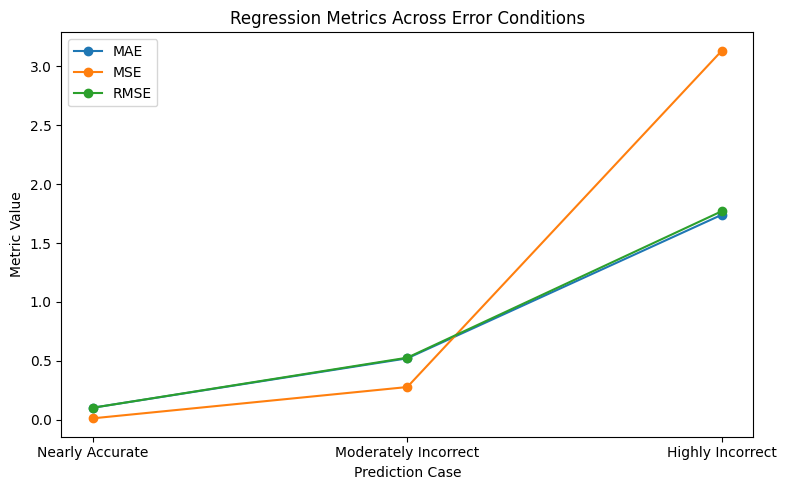

In [5]:
plt.figure(figsize=(8, 5))
for col in ['MAE', 'MSE', 'RMSE']:
    plt.plot(df.index, df[col], marker='o', label=col)
plt.title('Regression Metrics Across Error Conditions')
plt.ylabel('Metric Value')
plt.xlabel('Prediction Case')
plt.legend()
plt.tight_layout()
plt.show()

## Task 3

In [6]:
y_true = np.array([0, 1, 0, 1, 0, 1, 1, 0])
y_pred = np.array([0, 1, 0, 0, 0, 1, 1, 1])
def confusion_matrix_scratch(y, yhat):
    TP = np.sum((y == 1) & (yhat == 1))
    TN = np.sum((y == 0) & (yhat == 0))
    FP = np.sum((y == 0) & (yhat == 1))
    FN = np.sum((y == 1) & (yhat == 0))
    return np.array([[TN, FP], [FN, TP]]), TP, TN, FP, FN

cm_scratch, TP, TN, FP, FN = confusion_matrix_scratch(y_true, y_pred)

acc_s   = (TP + TN) / (TP + TN + FP + FN)
prec_s  = TP / (TP + FP) if (TP + FP) > 0 else 0
rec_s   = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_s    = 2 * prec_s * rec_s / (prec_s + rec_s) if (prec_s + rec_s) > 0 else 0

print("Confusion Matrix (Scratch):\n", cm_scratch)
print(f"\n{'Metric':<12} {'Scratch':>8} {'Sklearn':>8}")
print(f"{'Accuracy':<12} {acc_s:>8.4f} {accuracy_score(y_true, y_pred):>8.4f}")
print(f"{'Precision':<12} {prec_s:>8.4f} {precision_score(y_true, y_pred):>8.4f}")
print(f"{'Recall':<12} {rec_s:>8.4f} {recall_score(y_true, y_pred):>8.4f}")
print(f"{'F1 Score':<12} {f1_s:>8.4f} {f1_score(y_true, y_pred):>8.4f}")

Confusion Matrix (Scratch):
 [[3 1]
 [1 3]]

Metric        Scratch  Sklearn
Accuracy       0.7500   0.7500
Precision      0.7500   0.7500
Recall         0.7500   0.7500
F1 Score       0.7500   0.7500


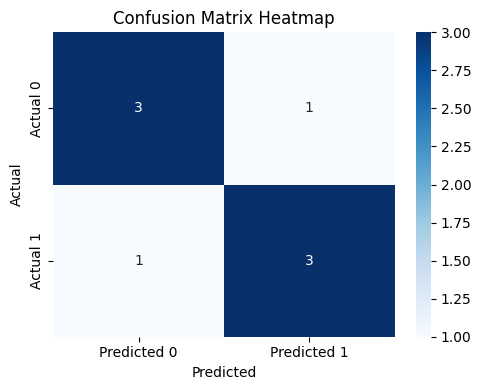

In [7]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix Heatmap')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Task 4

In [8]:
y_true       = np.array([0, 1, 0, 1, 0, 1, 1, 0])
y_pred_proba = np.array([0.1, 0.9, 0.2, 0.4, 0.3, 0.8, 0.7, 0.6])

roc_auc = roc_auc_score(y_true, y_pred_proba)
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

for thresh in [0.5, 0.7]:
    y_thresh = (y_pred_proba >= thresh).astype(int)
    acc = accuracy_score(y_true, y_thresh)
    print(f"Threshold {thresh}: labels={y_thresh.tolist()}, Accuracy={acc:.4f}")

ROC-AUC Score: 0.9375
Threshold 0.5: labels=[0, 1, 0, 0, 0, 1, 1, 1], Accuracy=0.7500
Threshold 0.7: labels=[0, 1, 0, 0, 0, 1, 1, 0], Accuracy=0.8750


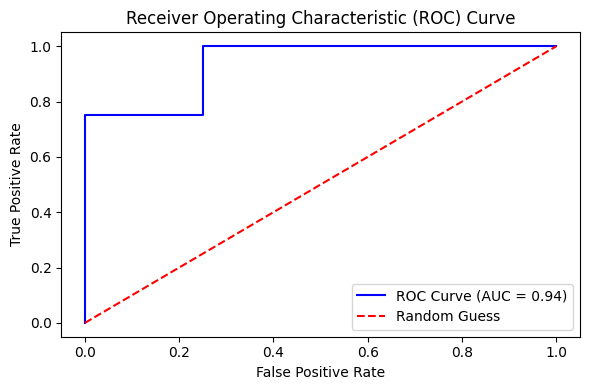

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

## Task 5

In [10]:
y_true       = np.array([0, 1, 0, 1, 0, 1, 1, 0])
y_pred       = np.array([0, 1, 0, 0, 0, 1, 1, 1])
y_pred_proba = np.array([0.1, 0.9, 0.2, 0.4, 0.3, 0.8, 0.7, 0.6])

print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision : {precision_score(y_true, y_pred):.4f}")
print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_true, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_true, y_pred_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred))

Accuracy  : 0.7500
Precision : 0.7500
Recall    : 0.7500
F1 Score  : 0.7500
ROC-AUC   : 0.9375

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.75      0.75      0.75         4

    accuracy                           0.75         8
   macro avg       0.75      0.75      0.75         8
weighted avg       0.75      0.75      0.75         8



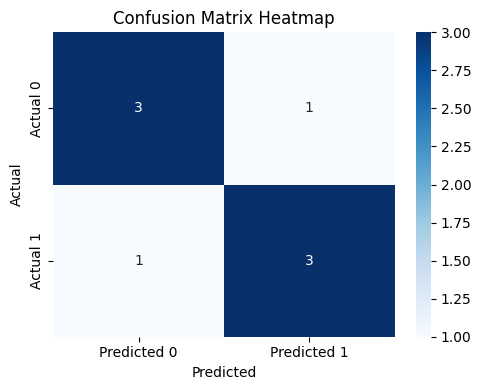

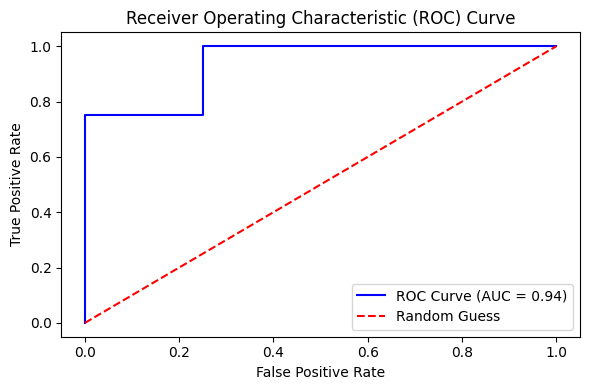

In [11]:
# Confusion Matrix heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix Heatmap')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ROC Curve
roc_auc = roc_auc_score(y_true, y_pred_proba)
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()